# qwen3.ipynb — Full Pipeline

Полный pipeline: индексация → поиск → оценка.

Для запуска настрой параметры в секции **2. Настройка**, затем выполни ячейки сверху вниз.

## 1. Импорты

In [23]:
import sys
sys.path.insert(0, '.')

import torch
# Захватываем CUDA-контекст на нужном устройстве ДО импорта decord.
# Decord при импорте инициализирует CUDA на GPU 0 по умолчанию,
# что конфликтует с device_map='cuda:X' в transformers.
torch.cuda.set_device(2)
_ = torch.zeros(1, device='cuda:2')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

import config
from utils.download import load_annotations
from utils.frames import extract_frames
from utils.qwen_embedder import Embedder
from utils.indexing import build_index, save_index, load_index
from utils.search import search_index, group_segments
from utils.metrics import compute_metrics, per_query_stats, iou_with_windows, KS

## 2. Настройка

Измени параметры ниже — остальные секции адаптируются автоматически.

In [24]:
# ── Модель эмбеддера ──────────────────────────────────────────
EMBED_MODEL_NAME = "Qwen/Qwen3-VL-Embedding-8B" # config.EMBED_MODEL_NAME / "Qwen/Qwen3-VL-Embedding-2B"
EMBED_DEVICE     = config.EMBED_DEVICE        # "cuda:2"

# ── Режим индексации ──────────────────────────────────────────
INDEX_TYPE  = "window"   # "frame" | "window"
WINDOW_SIZE = 6 # int(config.WINDOW_SIZE_SEC)   # сек; используется только при INDEX_TYPE == "window"
WINDOW_STEP = 3 # int(config.WINDOW_STEP_SEC)   # сек; шаг окна

# ── Reranker ──────────────────────────────────────────────────
USE_RERANKER     = False
RERANKER_MODEL   = config.RERANKER_MODEL_NAME   # "Qwen/Qwen3-VL-Reranker-2B"
RERANKER_DEVICE  = config.RERANKER_DEVICE        # "cuda:2"

# ── Поиск ─────────────────────────────────────────────────────
SEARCH_K = config.SEARCH_K   # кандидатов из индекса

# ── Производные пути (не менять) ──────────────────────────────
INDEX_DIR = config.INDEX_FRAME_DIR if INDEX_TYPE == "frame" else config.INDEX_WINDOW_DIR
GAP_SEC   = config.GAP_FRAME_SEC  if INDEX_TYPE == "frame" else config.GAP_WINDOW_SEC

config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
INDEX_DIR.mkdir(parents=True, exist_ok=True)

print(f"INDEX_TYPE   : {INDEX_TYPE}")
print(f"WINDOW_SIZE  : {WINDOW_SIZE} sec  (only for window mode)")
print(f"USE_RERANKER : {USE_RERANKER}")
print(f"EMBED_MODEL  : {EMBED_MODEL_NAME}")
print(f"INDEX_DIR    : {INDEX_DIR}")
print(f"RESULTS_DIR  : {config.RESULTS_DIR}")

INDEX_TYPE   : window
WINDOW_SIZE  : 6 sec  (only for window mode)
USE_RERANKER : False
EMBED_MODEL  : Qwen/Qwen3-VL-Embedding-8B
INDEX_DIR    : /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/index_window
RESULTS_DIR  : /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/results


## 3. Загрузка моделей

In [25]:
embedder = Embedder(EMBED_MODEL_NAME, EMBED_DEVICE)
print(f"Embedder loaded: {EMBED_MODEL_NAME} on {EMBED_DEVICE}")

if USE_RERANKER:
    from utils.reranker import load_reranker, rerank_segments
    reranker = load_reranker(RERANKER_MODEL, RERANKER_DEVICE)
    print(f"Reranker loaded: {RERANKER_MODEL} on {RERANKER_DEVICE}")
else:
    reranker = None
    print("Reranker: disabled")

Loading weights: 100%|██████████| 749/749 [00:03<00:00, 204.67it/s]


Embedder loaded: Qwen/Qwen3-VL-Embedding-8B on cuda:2
Reranker: disabled


## 4. Индексация

Строит FAISS-индекс для выбранного `INDEX_TYPE`.
- `frame`: 1 вектор/сек, `embed_images`
- `window`: 1 вектор/WINDOW_SIZE сек, `embed_windows`

In [26]:
vid_to_split: dict[str, str] = {}
for split in config.SPLITS:
    path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
    if path.exists():
        for item in load_annotations(path):
            vid_to_split[item["vid"]] = split

print(f"Known vids: {len(vid_to_split)}")

Known vids: 105


In [27]:
all_vectors: list[np.ndarray] = []
all_meta: list[dict] = []
faiss_id = 0

video_paths = sorted(config.VIDEO_DIR.glob("*.mp4"))
print(f"Videos to index: {len(video_paths)}  |  INDEX_TYPE={INDEX_TYPE}")

for video_path in tqdm(video_paths, desc="Videos"):
    video_id = video_path.stem
    split = vid_to_split.get(video_id, "unknown")
    frames = extract_frames(video_path, fps=config.SAMPLE_FPS)

    if INDEX_TYPE == "frame":
        batch_size = config.EMBED_BATCH_SIZE_FRAMES
        for batch_start in range(0, len(frames), batch_size):
            batch = frames[batch_start : batch_start + batch_size]
            images = [img for _, img in batch]
            vecs = embedder.embed_images(images)
            for i, (ts, _) in enumerate(batch):
                all_vectors.append(vecs[i])
                all_meta.append({
                    "faiss_id": faiss_id,
                    "video_id": video_id,
                    "start_sec": float(int(ts)),
                    "end_sec":   float(int(ts) + 1),
                    "timestamp_sec": ts,
                    "split": split,
                })
                faiss_id += 1
    else:  # window
        step = WINDOW_STEP
        size = WINDOW_SIZE
        windows: list[tuple[float, float, list]] = []
        for w_start in range(0, len(frames) - size + 1, step):
            window_frames = frames[w_start : w_start + size]
            start_sec = float(w_start)
            end_sec   = float(w_start + size)
            imgs = [img for _, img in window_frames]
            windows.append((start_sec, end_sec, imgs))

        batch_size = config.EMBED_BATCH_SIZE_WINDOWS
        for batch_start in range(0, len(windows), batch_size):
            batch = windows[batch_start : batch_start + batch_size]
            window_imgs = [imgs for _, _, imgs in batch]
            vecs = embedder.embed_windows(window_imgs)
            for i, (start_sec, end_sec, _) in enumerate(batch):
                ts = (start_sec + end_sec) / 2.0
                all_vectors.append(vecs[i])
                all_meta.append({
                    "faiss_id": faiss_id,
                    "video_id": video_id,
                    "start_sec": start_sec,
                    "end_sec":   end_sec,
                    "timestamp_sec": ts,
                    "split": split,
                })
                faiss_id += 1

print(f"Total vectors: {len(all_vectors)}")

Videos to index: 105  |  INDEX_TYPE=window


Videos:   0%|          | 0/105 [00:00<?, ?it/s]

Videos: 100%|██████████| 105/105 [17:55<00:00, 10.24s/it]

Total vectors: 5109


In [28]:
vectors  = np.vstack(all_vectors).astype(np.float32)
metadata = pd.DataFrame(all_meta)

index = build_index(vectors)
save_index(index, metadata, INDEX_DIR)

print(f"Index saved to {INDEX_DIR}")
print(f"  index.ntotal : {index.ntotal:,}")
print(f"  metadata shape: {metadata.shape}")
print(metadata.head(3))

Index saved to /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/index_window
  index.ntotal : 5,109
  metadata shape: (5109, 6)
   faiss_id                video_id  start_sec  end_sec  timestamp_sec  split
0         0  --d84Ars5ng_60.0_210.0        0.0      6.0            3.0  train
1         1  --d84Ars5ng_60.0_210.0        3.0      9.0            6.0  train
2         2  --d84Ars5ng_60.0_210.0        6.0     12.0            9.0  train


> Индекс построен и сохранён. Для `frame`: ~15 651 векторов (105 видео × ≈149 сек), D=2048. Для `window`: ~7 824 вектора (105 видео × ≈74 окна), D=2048.

## 5. Поиск

Загружает индекс для выбранного `INDEX_TYPE`, прогоняет все запросы, опционально применяет reranker.

Выход: `data/qvhighlights/results/search_results.parquet`

In [29]:
index, meta = load_index(INDEX_DIR)
print(f"Index loaded: {index.ntotal:,} vectors  [{INDEX_TYPE}]")

annotations = []
for split in config.SPLITS:
    path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
    if path.exists():
        annotations.extend(load_annotations(path))
print(f"Queries: {len(annotations)}")

Index loaded: 5,109 vectors  [window]
Queries: 107


In [30]:
rows = []

for ann in tqdm(annotations, desc="Search"):
    qid        = ann["qid"]
    query      = ann["query"]
    gt_vid     = ann["vid"]
    gt_windows = str(ann["relevant_windows"])

    query_vec = embedder.embed_text([query])  # (1, D)
    hits = search_index(index, meta, query_vec, k=SEARCH_K)
    segs = group_segments(hits, gap_sec=GAP_SEC)

    for rank, (_, seg) in enumerate(segs.iterrows(), start=1):
        rows.append({
            "qid":        qid,
            "query":      query,
            "gt_vid":     gt_vid,
            "gt_windows": gt_windows,
            "index_type": INDEX_TYPE,
            "rank":       rank,
            "pred_vid":   seg["video_id"],
            "pred_start": seg["start_sec"],
            "pred_end":   seg["end_sec"],
            "score":      seg["score"],
        })

results = pd.DataFrame(rows)
print(f"Total rows: {len(results):,}")

Search: 100%|██████████| 107/107 [00:07<00:00, 14.21it/s]

Total rows: 3,418


In [31]:
del embedder
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [32]:
if USE_RERANKER:
    reranked_type = f"{INDEX_TYPE}_reranked"
    rerank_rows = []

    for ann in tqdm(annotations, desc="Reranking"):
        qid        = ann["qid"]
        query      = ann["query"]
        gt_vid     = ann["vid"]
        gt_windows = str(ann["relevant_windows"])

        subset = results[(results["qid"] == qid) & (results["index_type"] == INDEX_TYPE)]
        if subset.empty:
            continue

        segs = pd.DataFrame({
            "video_id":  subset["pred_vid"].values,
            "start_sec": subset["pred_start"].values,
            "end_sec":   subset["pred_end"].values,
            "score":     subset["score"].values,
        })

        reranked = rerank_segments(query, segs, config.VIDEO_DIR, reranker)

        for rank, (_, seg) in enumerate(reranked.iterrows(), start=1):
            rerank_rows.append({
                "qid":        qid,
                "query":      query,
                "gt_vid":     gt_vid,
                "gt_windows": gt_windows,
                "index_type": reranked_type,
                "rank":       rank,
                "pred_vid":   seg["video_id"],
                "pred_start": seg["start_sec"],
                "pred_end":   seg["end_sec"],
                "score":      seg["score"],
            })

    # Оставляем только reranked — base не сохраняем
    results = pd.DataFrame(rerank_rows)
    print(f"Total rows (reranked only): {len(results):,}")
else:
    print(f"Total rows: {len(results):,}")

print(results.groupby("index_type")["qid"].count().rename("rows"))

Total rows: 3,418
index_type
window    3418
Name: rows, dtype: int64


In [33]:
out_path = config.RESULTS_DIR / "search_results.parquet"
results.to_parquet(out_path, index=False)
print(f"Saved → {out_path}")
print(f"Shape: {results.shape}")
print()
print(results.head(6).to_string())

Saved → /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/results/search_results.parquet
Shape: (3418, 10)

    qid                            query                   gt_vid                                     gt_windows index_type  rank                 pred_vid  pred_start  pred_end     score
0  6898  Woman holds up her white pants.  S73Z-nM0GQE_660.0_810.0  [[90, 92], [98, 114], [122, 132], [134, 140]]     window     1  S73Z-nM0GQE_660.0_810.0        78.0     150.0  0.634519
1  6898  Woman holds up her white pants.  S73Z-nM0GQE_660.0_810.0  [[90, 92], [98, 114], [122, 132], [134, 140]]     window     2  uMc_B7RSays_660.0_810.0         0.0      33.0  0.599746
2  6898  Woman holds up her white pants.  S73Z-nM0GQE_660.0_810.0  [[90, 92], [98, 114], [122, 132], [134, 140]]     window     3  0oUU-4oBwrY_360.0_510.0        69.0      93.0  0.458841
3  6898  Woman holds up her white pants.  S73Z-nM0GQE_660.0_810.0  [[90, 92], [98, 114], [122, 132], [134, 140

> `search_results.parquet` сохранён — вход для секции 6 (Оценка).

## 6. Оценка

Метрики качества поиска + разбор полётов.

Вход: `search_results.parquet` из секции 5.
Метрики: Video Recall@K, MRR, mAP, Hit@1@IoU, Moment Recall@K@IoU, Mean IoU.

In [34]:
# Аннотации могут быть уже загружены в секции 5; перезагружаем для независимости
if "annotations" not in dir() or len(annotations) == 0:
    annotations = []
    for split in config.SPLITS:
        path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
        if path.exists():
            annotations.extend(load_annotations(path))

# results может быть уже в памяти из секции 5; если нет — грузим с диска
if "results" not in dir():
    results = pd.read_parquet(config.RESULTS_DIR / "search_results.parquet")
    # При загрузке с диска оставляем только одну конфигурацию согласно USE_RERANKER
    _expected_type = f"{INDEX_TYPE}_reranked" if USE_RERANKER else INDEX_TYPE
    if _expected_type in results["index_type"].unique():
        results = results[results["index_type"] == _expected_type].copy()

print(f"Results: {len(results):,} rows")
print(f"Queries: {results['qid'].nunique()}")
print(f"Index types: {results['index_type'].unique().tolist()}")

Results: 3,418 rows
Queries: 107
Index types: ['window']


### Сводная таблица метрик

In [35]:
all_types = results["index_type"].unique().tolist()
metrics_by_type = {}
for idx_type in all_types:
    subset = results[results["index_type"] == idx_type]
    metrics_by_type[idx_type] = compute_metrics(subset, annotations)

summary = pd.DataFrame(metrics_by_type).T
summary.index.name = "index_type"
print(summary.to_string(float_format=lambda x: f"{x:.3f}"))

            video_recall@1  video_recall@2  video_recall@3  video_recall@5  video_recall@10  video_recall@15  video_recall@20  video_precision@1  video_precision@2  video_precision@3  video_precision@5  video_precision@10  video_precision@15  video_precision@20  ndcg@1  ndcg@2  ndcg@3  ndcg@5  ndcg@10  ndcg@15  ndcg@20  video_f1@1  video_f1@2  video_f1@3  video_f1@5  video_f1@10  video_f1@15  video_f1@20  video_mrr  video_map  mean_iou  mean_iou@top1  mean_iou@top5  hit@1@iou03  moment_mrr@iou03  moment_recall@1@iou03  moment_precision@1@iou03  moment_recall@2@iou03  moment_precision@2@iou03  moment_recall@3@iou03  moment_precision@3@iou03  moment_recall@5@iou03  moment_precision@5@iou03  moment_recall@10@iou03  moment_precision@10@iou03  moment_recall@15@iou03  moment_precision@15@iou03  moment_recall@20@iou03  moment_precision@20@iou03  hit@1@iou05  moment_mrr@iou05  moment_recall@1@iou05  moment_precision@1@iou05  moment_recall@2@iou05  moment_precision@2@iou05  moment_recall@3@iou0

### Heatmap метрик

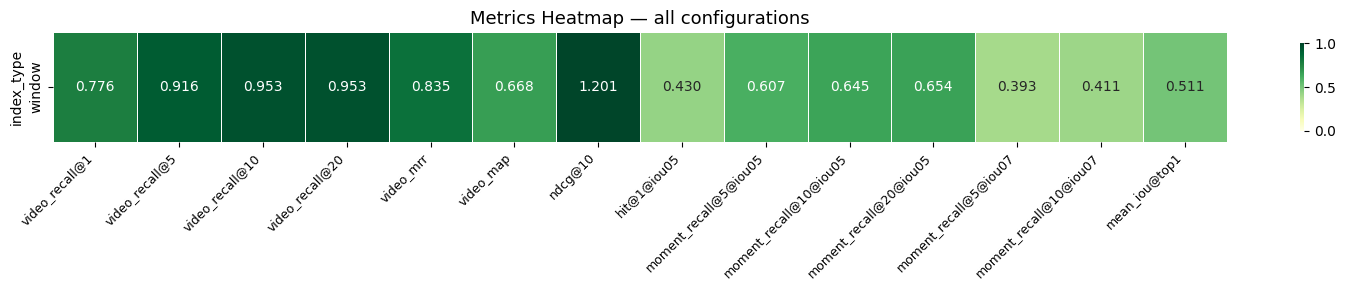

In [36]:
import seaborn as sns

HEATMAP_COLS = [
    "video_recall@1", "video_recall@5", "video_recall@10", "video_recall@20",
    "video_mrr", "video_map", "ndcg@10",
    "hit@1@iou05", "moment_recall@5@iou05", "moment_recall@10@iou05", "moment_recall@20@iou05",
    "moment_recall@5@iou07", "moment_recall@10@iou07",
    "mean_iou@top1",
]
heatmap_cols = [c for c in HEATMAP_COLS if c in summary.columns]
heatmap_df = summary[heatmap_cols]

fig, ax = plt.subplots(figsize=(max(14, len(heatmap_cols) * 1.1), max(3, len(summary) * 0.9)))
sns.heatmap(
    heatmap_df.astype(float),
    ax=ax,
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1,
    cmap="YlGn",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Metrics Heatmap — all configurations", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

### Recall@K кривые

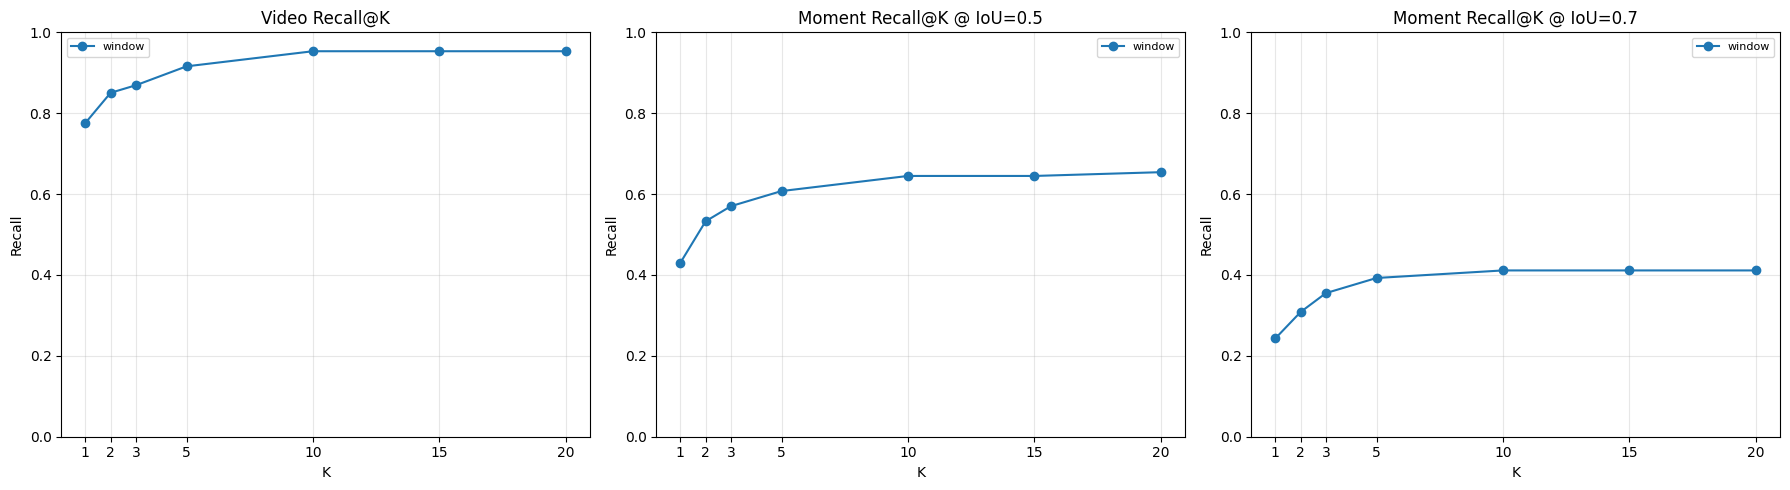

In [37]:
plots_spec = [
    ("Video Recall@K",            [f"video_recall@{k}"        for k in KS]),
    ("Moment Recall@K @ IoU=0.5", [f"moment_recall@{k}@iou05" for k in KS]),
    ("Moment Recall@K @ IoU=0.7", [f"moment_recall@{k}@iou07" for k in KS]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, cols) in zip(axes, plots_spec):
    for idx_type, row in summary.iterrows():
        vals = [row.get(c, float("nan")) for c in cols]
        ax.plot(KS, vals, marker="o", label=idx_type)
    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1)
    ax.set_xticks(KS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### IoU vs Rank кривая

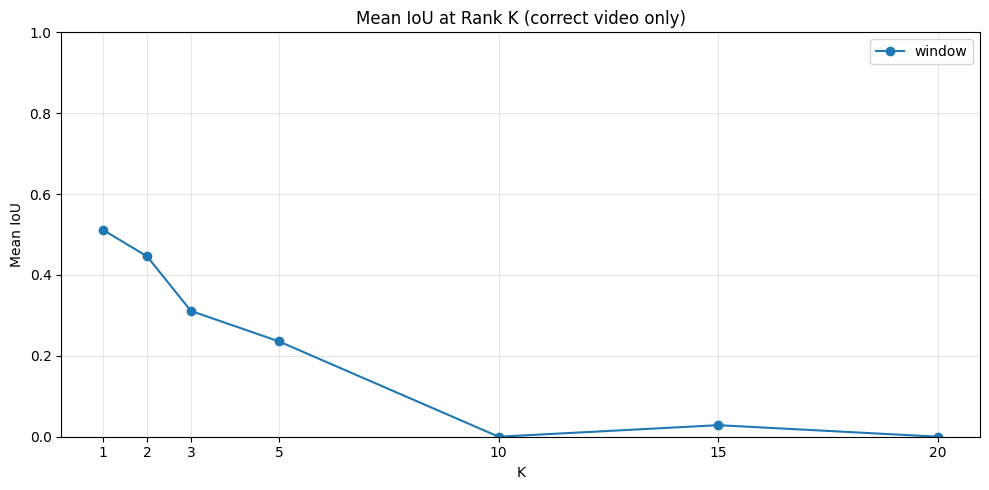

In [38]:
_ann_by_qid = {a["qid"]: a for a in annotations}

fig, ax = plt.subplots(figsize=(10, 5))
for idx_type in results["index_type"].unique():
    subset = results[results["index_type"] == idx_type]
    mean_ious = []
    for k in KS:
        rank_k_rows = subset[subset["rank"] == k]
        ious = []
        for _, row in rank_k_rows.iterrows():
            ann = _ann_by_qid.get(row["qid"])
            if ann is not None and row["pred_vid"] == ann["vid"]:
                ious.append(
                    iou_with_windows(row["pred_start"], row["pred_end"], ann["relevant_windows"])
                )
        mean_ious.append(float(np.mean(ious)) if ious else 0.0)
    ax.plot(KS, mean_ious, marker="o", label=idx_type)

ax.set_title("Mean IoU at Rank K (correct video only)")
ax.set_xlabel("K")
ax.set_ylabel("Mean IoU")
ax.set_ylim(0, 1)
ax.set_xticks(KS)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Video Retrieval

            video_recall@1  video_recall@5  video_recall@10  video_mrr  video_map
index_type                                                                       
window               0.776           0.916            0.953      0.835      0.668


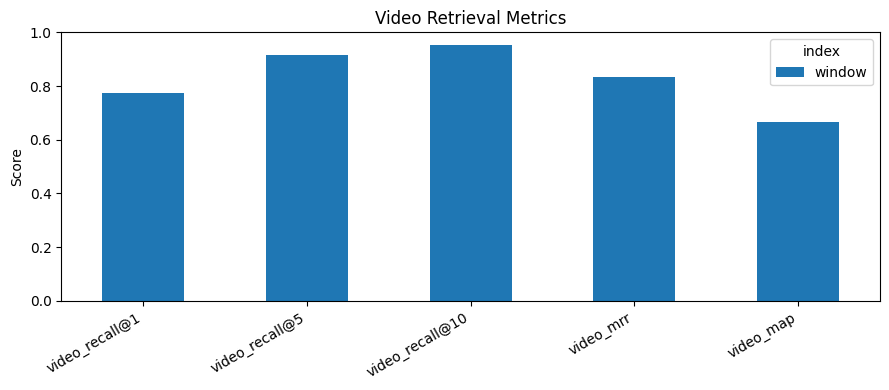

In [39]:
video_cols = ["video_recall@1", "video_recall@5", "video_recall@10", "video_mrr", "video_map"]
video_df = summary[video_cols]
print(video_df.to_string(float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(9, 4))
video_df.T.plot(kind="bar", ax=ax)
ax.set_title("Video Retrieval Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="index")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Moment Retrieval

            hit@1@iou03  hit@1@iou05  moment_recall@1@iou05  moment_recall@5@iou05  moment_recall@10@iou05  moment_mrr@iou05  mean_iou
index_type                                                                                                                            
window            0.542        0.430                  0.430                  0.607                   0.645             0.507     0.599


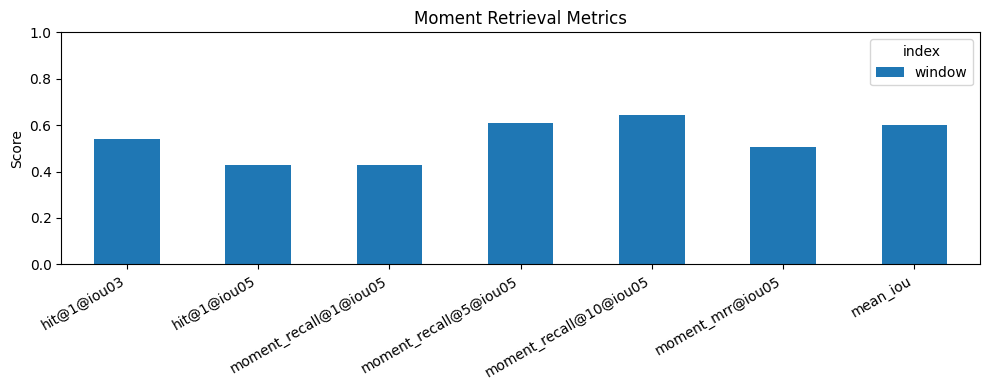

In [40]:
moment_cols = [
    "hit@1@iou03", "hit@1@iou05",
    "moment_recall@1@iou05", "moment_recall@5@iou05", "moment_recall@10@iou05",
    "moment_mrr@iou05", "mean_iou",
]
moment_df = summary[moment_cols]
print(moment_df.to_string(float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(10, 4))
moment_df.T.plot(kind="bar", ax=ax)
ax.set_title("Moment Retrieval Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="index")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Распределения

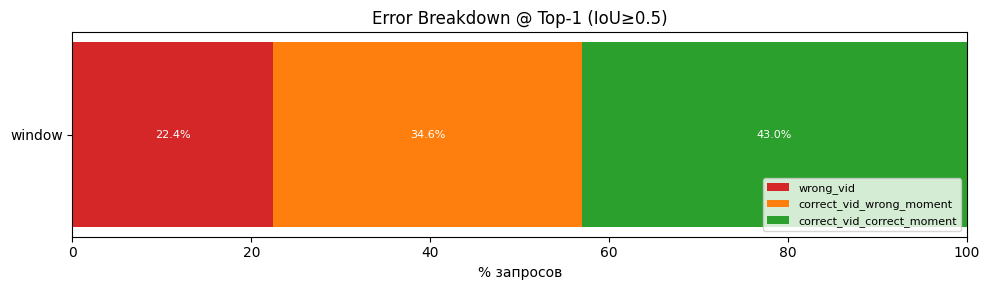

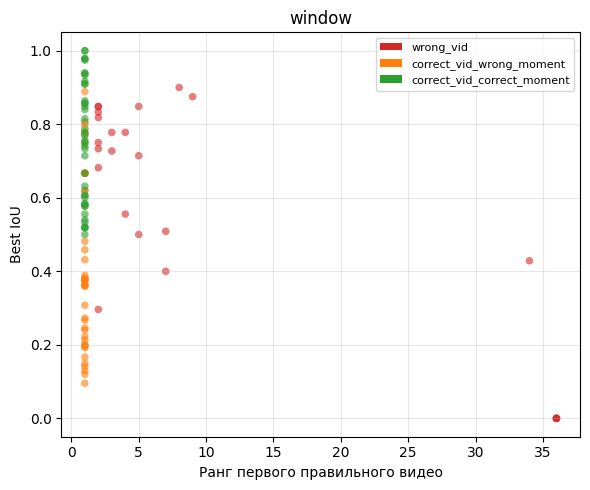

/tmp/ipykernel_2421098/2207401429.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, notch=False)


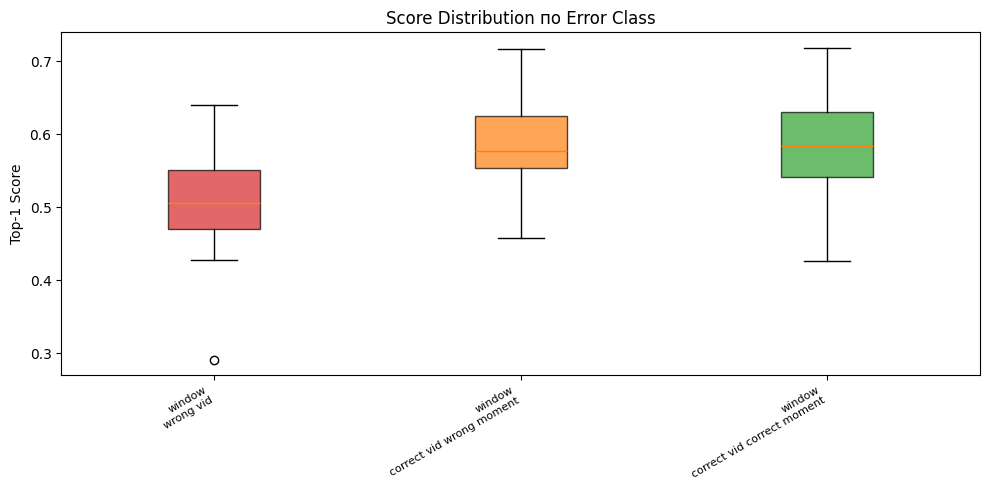

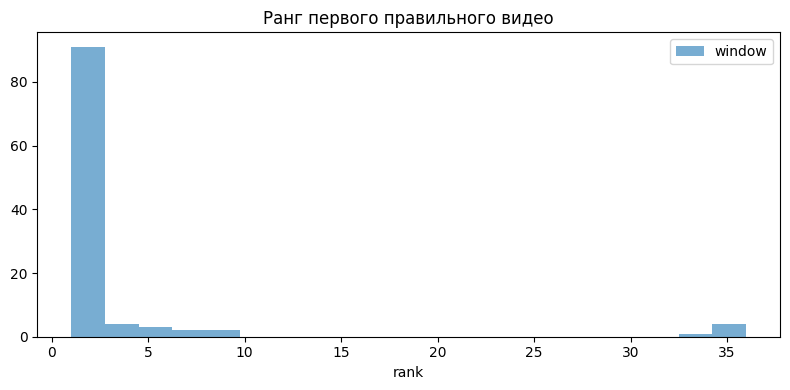

In [41]:
stats = per_query_stats(results, annotations)

_ERROR_COLORS = {
    "wrong_vid":                  "#d62728",
    "correct_vid_wrong_moment":   "#ff7f0e",
    "correct_vid_correct_moment": "#2ca02c",
}
_CATEGORIES = list(_ERROR_COLORS.keys())

# ── Error Breakdown ────────────────────────────────────────────
error_counts = stats.groupby(["index_type", "error_class"]).size().unstack(fill_value=0)
total_per_type = stats.groupby("index_type").size()
error_pct = error_counts.div(total_per_type, axis=0) * 100
for cat in _CATEGORIES:
    if cat not in error_pct.columns:
        error_pct[cat] = 0.0
error_pct = error_pct[_CATEGORIES]

fig, ax = plt.subplots(figsize=(10, max(3, len(error_pct) * 0.9)))
left = np.zeros(len(error_pct))
for cat in _CATEGORIES:
    vals = error_pct[cat].values
    bars = ax.barh(error_pct.index, vals, left=left, color=_ERROR_COLORS[cat], label=cat)
    for bar, v in zip(bars, vals):
        if v > 3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%", ha="center", va="center", fontsize=8, color="white",
            )
    left += vals
ax.set_xlabel("% запросов")
ax.set_title("Error Breakdown @ Top-1 (IoU≥0.5)")
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

# ── Per-query Scatter ──────────────────────────────────────────
idx_types = stats["index_type"].unique()
_max_rank = stats["first_correct_video_rank"].replace(float("inf"), 0).max()

fig, axes = plt.subplots(1, len(idx_types), figsize=(6 * len(idx_types), 5))
if len(idx_types) == 1:
    axes = [axes]

for ax, idx_type in zip(axes, idx_types):
    grp = stats[stats["index_type"] == idx_type]
    ranks = grp["first_correct_video_rank"].replace(float("inf"), _max_rank + 2)
    colors_s = [_ERROR_COLORS.get(c, "gray") for c in grp["error_class"]]
    ax.scatter(ranks, grp["best_iou"], c=colors_s, alpha=0.6, s=30, edgecolors="none")
    ax.set_title(idx_type)
    ax.set_xlabel("Ранг первого правильного видео")
    ax.set_ylabel("Best IoU")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=v, label=k) for k, v in _ERROR_COLORS.items()]
axes[-1].legend(handles=legend_elems, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# ── Score Distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(idx_types) * len(_CATEGORIES) * 1.2), 5))
box_data, box_labels, box_colors = [], [], []
for idx_type in idx_types:
    for cat in _CATEGORIES:
        subset = stats[(stats["index_type"] == idx_type) & (stats["error_class"] == cat)]
        if not subset.empty:
            box_data.append(subset["top1_score"].values)
            box_labels.append(f"{idx_type}\n{cat.replace('_', ' ')}")
            box_colors.append(_ERROR_COLORS[cat])

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Top-1 Score")
ax.set_title("Score Distribution по Error Class")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

# ── Ранг первого правильного видео (гистограмма) ───────────────
fig, ax = plt.subplots(figsize=(8, 4))
for idx_type, grp in stats.groupby("index_type"):
    finite_ranks = grp["first_correct_video_rank"].replace(float("inf"), _max_rank + 2)
    ax.hist(finite_ranks, bins=20, alpha=0.6, label=idx_type)
ax.set_title("Ранг первого правильного видео")
ax.set_xlabel("rank")
ax.legend()
plt.tight_layout()
plt.show()

### Разбор полётов

In [42]:
cols_show = ["query", "first_correct_video_rank", "best_iou", "top1_score"]
for idx_type in results["index_type"].unique():
    grp = stats[stats["index_type"] == idx_type].sort_values("first_correct_video_rank")
    print(f"\n=== {idx_type.upper()} — Топ-5 лучших ===")
    print(grp.head(5)[cols_show].to_string(index=False))
    finite = grp[grp["first_correct_video_rank"] < float("inf")]
    print(f"\n=== {idx_type.upper()} — Топ-5 худших (из найденных) ===")
    print(finite.tail(5)[cols_show].to_string(index=False))

# Провалы
failures = stats[stats["first_correct_video_rank"] > 10].sort_values(
    "first_correct_video_rank", ascending=False
)
print(f"\nПровалов (rank > 10): {len(failures)}")
cols_f = ["index_type", "query", "gt_vid", "first_correct_video_rank", "top1_vid", "top1_score"]
print(failures[cols_f].to_string(index=False))

# Галлюцинации
wrong_top1 = stats[stats["top1_vid"] != stats["gt_vid"]].sort_values("top1_score", ascending=False)
print(f"\nЗапросов с неправильным top-1: {len(wrong_top1)}")
cols_w = ["index_type", "query", "gt_vid", "top1_vid", "top1_score"]
print(wrong_top1.head(10)[cols_w].to_string(index=False))

# Правильное видео, плохой момент
right_vid_wrong_moment = stats[
    (stats["top1_vid"] == stats["gt_vid"]) & (stats["top1_iou"] < 0.3)
].sort_values("top1_iou")
print(f"\nПравильное видео + плохой момент (IoU < 0.3): {len(right_vid_wrong_moment)}")
cols_r = ["index_type", "query", "gt_vid", "top1_iou", "top1_score"]
print(right_vid_wrong_moment[cols_r].to_string(index=False))


=== WINDOW — Топ-5 лучших ===
                                           query  first_correct_video_rank  best_iou  top1_score
          Blonde woman holds up food in her car.                       1.0  0.388889    0.576137
Woman wears a white top walking down the street.                       1.0  0.769231    0.517456
Man in baseball cap is riding in a car at night.                       1.0  0.600000    0.631259
   Muslim woman is organizing clothes into bags.                       1.0  0.848485    0.595399
         Chef peels an onion on a cutting board.                       1.0  0.213333    0.688293

=== WINDOW — Топ-5 худших (из найденных) ===
                                                                       query  first_correct_video_rank  best_iou  top1_score
Woman in red top monologues with with white pillows on the couch behind her.                       7.0  0.508772    0.573347
                                 Man walks along water alone on a windy day.               

### Threshold Analysis (reranked)

In [43]:
if USE_RERANKER:
    thresholds = np.arange(0.10, 0.95, 0.05)
    metrics_to_plot = [
        "video_recall@1",          "video_recall@5",          "video_recall@10",
        "hit@1@iou05",             "moment_recall@5@iou05",   "moment_recall@10@iou05",
        "hit@1@iou07",             "moment_recall@5@iou07",   "moment_recall@10@iou07",
    ]
    sweep = {m: [] for m in metrics_to_plot}

    for t in thresholds:
        filtered = results[results["score"] >= t]
        m = compute_metrics(filtered, annotations)
        for metric in metrics_to_plot:
            sweep[metric].append(m.get(metric, 0.0))

    run_label = results["index_type"].iloc[0]
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()
    for ax, metric in zip(axes, metrics_to_plot):
        ax.plot(thresholds, sweep[metric], marker="o", label=run_label)
        ax.set_title(metric)
        ax.set_xlabel("threshold")
        ax.set_ylabel("score")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle(f"Reranker Threshold Sweep — {run_label}")
    plt.tight_layout()
    plt.show()

    print("Оптимальные пороги:")
    for metric in metrics_to_plot:
        best_t = thresholds[int(np.argmax(sweep[metric]))]
        best_v = max(sweep[metric])
        print(f"  [{metric}] threshold={best_t:.2f} → {best_v:.3f}")
else:
    print("USE_RERANKER=False — threshold analysis пропущен")

USE_RERANKER=False — threshold analysis пропущен


## 7. ClearML

Логирует эксперимент в ClearML. Имя эксперимента генерируется автоматически из параметров секции 2.

In [44]:
os.environ.setdefault("CLEARML_CONFIG_FILE", "clearml.conf")

from utils.clearml_logger import log_experiment

# Имя эксперимента собирается из параметров секции 2
_model_short = EMBED_MODEL_NAME.split("/")[-1]   # "Qwen3-VL-Embedding-2B"
_reranker_suffix = "+reranker" if USE_RERANKER else ""
_size_and_step = f'size={WINDOW_SIZE}/step={WINDOW_STEP}' if INDEX_TYPE == "window" else ""
task_name = f"{_model_short} / {INDEX_TYPE}{_reranker_suffix} {_size_and_step}".strip()
# Примеры:
#   "Qwen3-VL-Embedding-2B / frame+reranker"
#   "Qwen3-VL-Embedding-2B / window"

log_experiment(
    task_name=task_name,
    config_dict={
        k: v for k, v in vars(config).items()
        if not k.startswith("_") and not callable(v)
    },
    results_df=results,
    annotations=annotations,
    extra_params={
        "index_type":   INDEX_TYPE,
        "window_size":  WINDOW_SIZE if INDEX_TYPE == "window" else None,
        "use_reranker": USE_RERANKER,
    },
)
print(f"Logged to ClearML ✓  task_name={task_name!r}")

Logged to ClearML ✓  task_name='Qwen3-VL-Embedding-8B / window size=6/step=3'
